In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv(r"/content/Customer Churn (2).csv")

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [ ]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
99995,99996,31,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,99997,64,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,99998,48,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,99999,42,Female,60,114.00,Month-to-month,Mailed check,6826.55,No
99999,100000,72,Male,57,66.76,One year,Credit card,3828.60,No


In [ ]:
df.shape

(100000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop(['CustomerID'], axis=1)

In [ ]:
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,49.027240,36.527090,79.974933,2926.140256
std,18.177862,20.789552,40.491961,2388.163672
min,18.000000,1.000000,10.000000,-118.430000
25%,33.000000,18.000000,44.720000,963.667500
50%,49.000000,37.000000,80.000000,2268.060000
75%,65.000000,54.000000,115.050000,4394.327500
max,80.000000,72.000000,150.000000,10831.460000


In [ ]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,66.856
Yes,33.144


In [ ]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].nunique())

Gender 3
Contract 3
PaymentMethod 4
Churn 2


In [ ]:
df.groupby('Churn')['Tenure'].mean()

,Tenure
Churn,
No,39.321796
Yes,30.889784


In [ ]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.534426,0.465574
One year,0.832509,0.167491
Two year,0.831215,0.168785


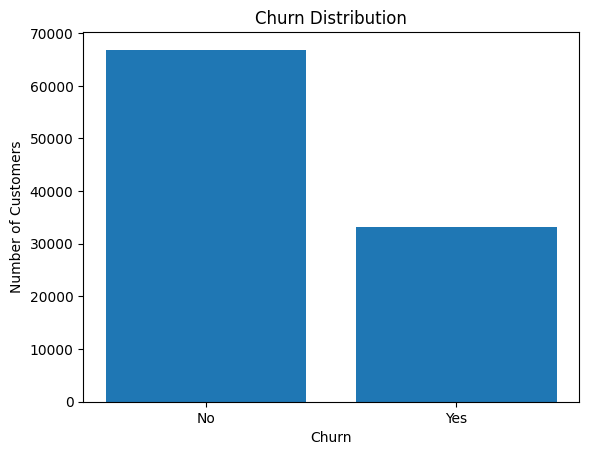

In [ ]:
churn_counts = df['Churn'].value_counts()

plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

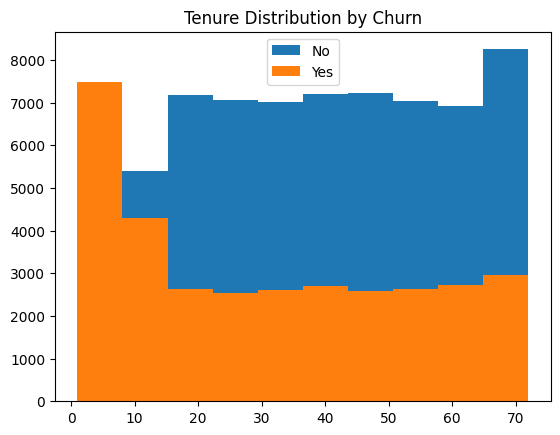

In [ ]:
plt.hist(df[df['Churn']=='No']['Tenure'], label='No')
plt.hist(df[df['Churn']=='Yes']['Tenure'],  label='Yes')
plt.legend()
plt.title("Tenure Distribution by Churn")
plt.show()

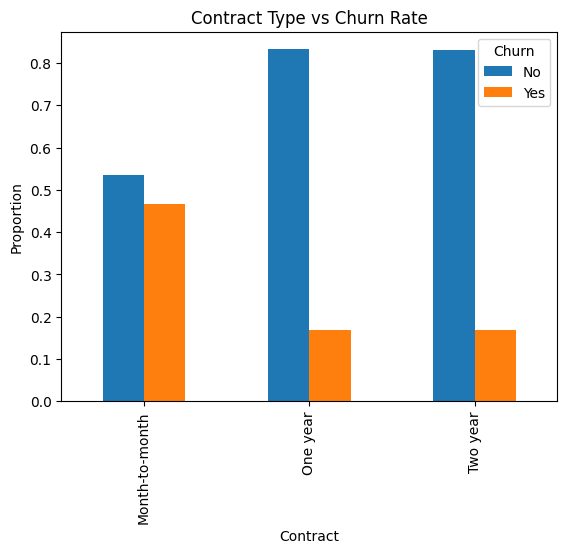

In [ ]:
contract_churn_norm = pd.crosstab(df['Contract'], df['Churn'], normalize = 'index')
contract_churn_norm.plot(kind='bar')
plt.title("Contract Type vs Churn Rate")
plt.ylabel("Proportion")
plt.show()

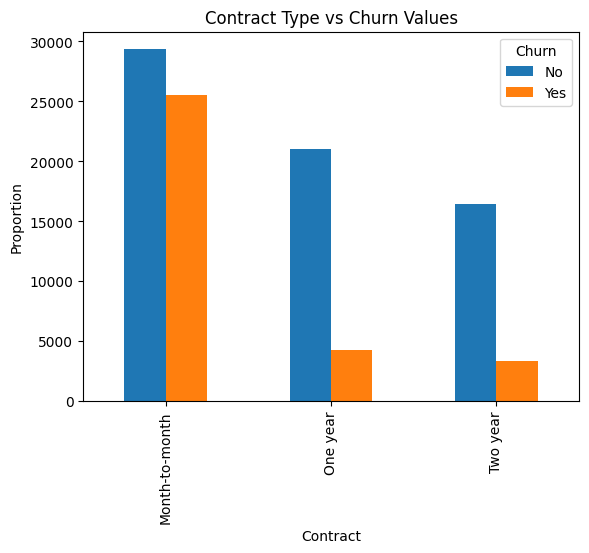

In [ ]:
contract_churn_norm = pd.crosstab(df['Contract'], df['Churn'])
contract_churn_norm.plot(kind='bar')
plt.title("Contract Type vs Churn Values")
plt.ylabel("Proportion")
plt.show()

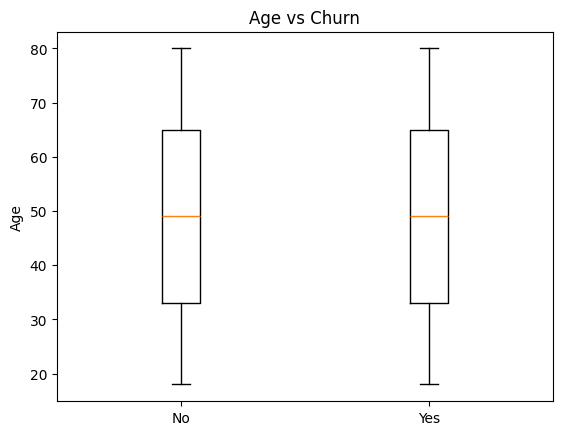

In [ ]:
plt.boxplot([
    df[df['Churn']=='No']['Age'],
    df[df['Churn']=='Yes']['Age']
])

plt.xticks([1,2], ['No','Yes'])
plt.ylabel("Age")
plt.title("Age vs Churn")
plt.show()

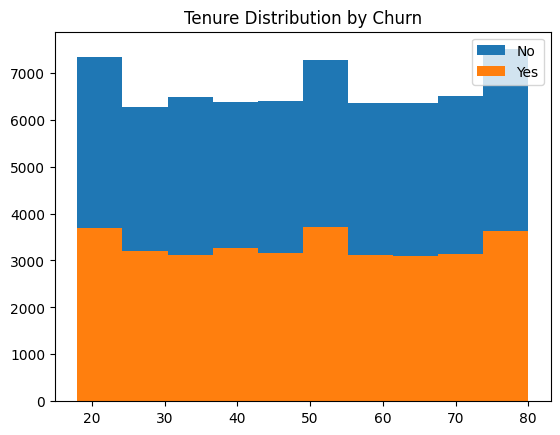

In [ ]:
plt.hist(df[df['Churn']=='No']['Age'], label='No')
plt.hist(df[df['Churn']=='Yes']['Age'],  label='Yes')
plt.legend()
plt.title("Tenure Distribution by Churn")
plt.show()

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,72.845838
Yes,94.355298


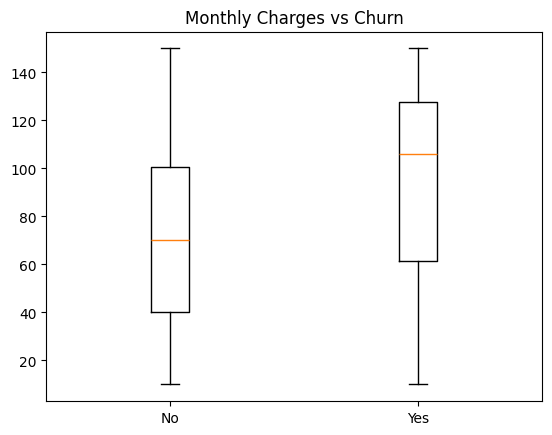

In [ ]:
plt.boxplot([
    df[df['Churn']=='No']['MonthlyCharges'],
    df[df['Churn']=='Yes']['MonthlyCharges']
])
plt.xticks([1,2], ['No','Yes'])
plt.title("Monthly Charges vs Churn")
plt.show()

In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer,0.669957,0.330043
Credit card,0.672075,0.327925
Electronic check,0.667116,0.332884
Mailed check,0.666667,0.333333
